In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import lognorm,norm,rv_continuous

from elfdannagalac.dmsrc import DMHalo,NFW_profile,get_c_sub
from elfdannagalac.substructure import p_nsub_m,p_nsub_c,p_nsub_v,rhosub
from elfdannagalac.substructure import SubHaloPopulation


In [2]:
r200 = 3e3*u.kpc
m200 = 3.545e14*u.Msun


abel_cluster = DMHalo(
    "Abel",
    12*u.deg,
    27*u.deg,
    0.0308,
    m200,
    r200,
    dmsigmav=3.6e-24*u.cm**3/u.s,
    msub_min=3.5410271e9*u.Msun,
    msub_max=3.54e12*u.Msun,
    fsub=0.11,
    mpoints=5
)


2026-04-10 05:19:38.881 | WARNING  | elfdannagalac.dmsrc.halo:__init__:141 - Input R200 3000.000 kpc will be inconsistent with the rest of calculations.
 Setting R200 to the value obtained using the critical density: 1406.363 kpc
2026-04-10 05:20:07.624 | INFO     | elfdannagalac.dmsrc.halo:get_msub:643 - Computing mass in form of subhalos


In [3]:
abel_cluster.info

2026-04-10 05:22:19.818 | INFO     | elfdannagalac.dmsrc.halo:info:384 - 
Abel cluster configured with: 
	- Redshift: 0.031
	- D_lum: 129474.231 kpc
	- Coord: (12.000 deg,27.000 deg) [ICRS]
	- X: 112.841 Mpc
	- Y: 23.985 Mpc
	- Z: 58.780 Mpc
	- Cluster Radius [R200]: 1406.363 kpc
	- Total Mass [M200]: 3.545e+14 solMass
	- Scale radius: 86.108 kpc
	- Scale density: 2.313e+07 solMass / kpc3
	- Saturation Radius: 2.390e-07 kpc
	- Saturation Density: 8.333e+15 solMass / kpc3
	- Number of subhalos: 1116  (from [3.541e+09 solMass,3.540e+12 solMass])
	- Total mass in form of subhalos: 3.897e+13 solMass (11.0% of the cluster mass)
	- Annihilation emissivity [No sub]: 1.431e+21 solMass2 / kpc3 (6.058e+70 GeV2 / cm3)
	- Annihilation emissivity [With sub]: 1.133e+21 solMass2 / kpc3 (4.799e+70 GeV2 / cm3)
	- Decay emissivity [No sub]: 3.545e+14 solMass (3.954e+71 GeV)
	- DM luminosity [Annihilation, No sub]: 3.49407e+42 erg / s
	- DM luminosity [Annihilation, With sub]: 2.76809e+42 erg / s
	- DM l

In [4]:
abel_cluster.nsubs

1116

In [5]:
rvals = np.logspace(-2,np.log10(abel_cluster.r200.value),50)*abel_cluster.r200.unit

rhosub_vals = np.zeros_like(rvals.value)*u.Msun/abel_cluster.r200.unit**3

for i,r in enumerate(rvals):

    rhosub_vals[i] = abel_cluster.rho_sub(r)


Text(0, 0.5, '$\\rho_\\text{sub}$ [$M_\\odot$ kpc$^{-3}$]')

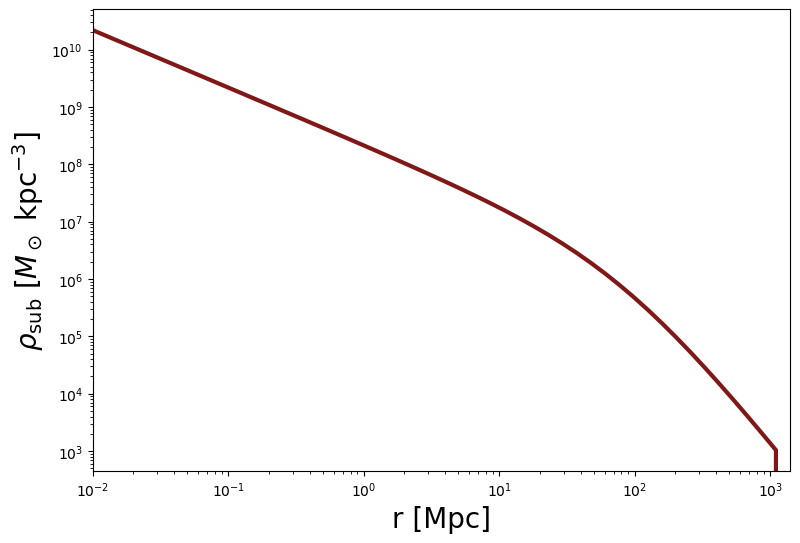

In [6]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(rvals,rhosub_vals,lw=3,color="#801818")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.01,abel_cluster.r200.value)
ax.set_xlabel("r [Mpc]",fontsize=20)
ax.set_ylabel(r"$\rho_\text{sub}$ [$M_\odot$ kpc$^{-3}$]",fontsize=20)

In [7]:
rvals = np.logspace(-2,np.log10(abel_cluster.r200.value),50)*abel_cluster.r200.unit

rhosub_vals = np.zeros_like(rvals.value)*u.Msun/abel_cluster.r200.unit**3
rhotot_vals = np.zeros_like(rvals.value)*u.Msun/abel_cluster.r200.unit**3

for i,r in enumerate(rvals):

    rhosub_vals[i] = abel_cluster.rho_sub(r)
    rhotot_vals[i] = abel_cluster.rho_tot(r)

rho_smooth = rhotot_vals - rhosub_vals


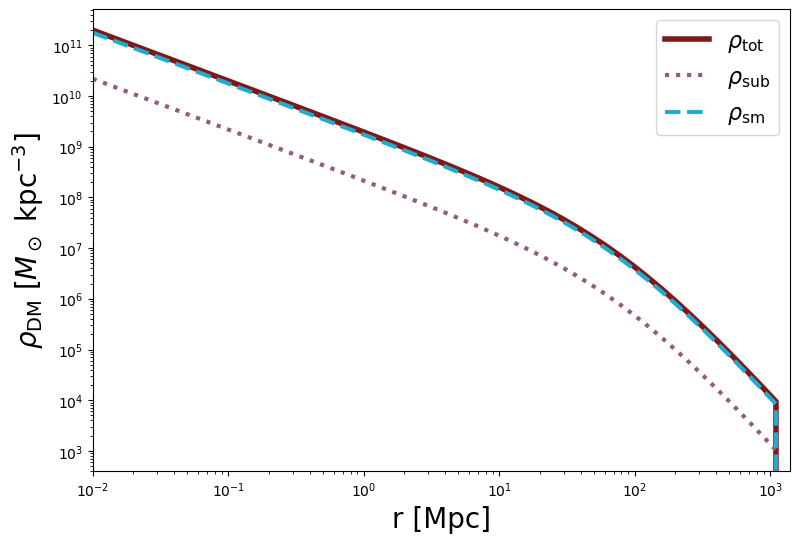

In [ ]:
fig,ax = plt.subplots(figsize=(9,6))

ax.plot(rvals,rhotot_vals,lw=4,color="#801818",ls="-",label=r"$\rho_\text{tot}$")
ax.plot(rvals,rhosub_vals,lw=3,color="#915C83",ls=":",label=r"$\rho_\text{sub}$")
ax.plot(rvals,rho_smooth,lw=3,color="#21ABCD",ls="--",label=r"$\rho_\text{sm}$")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(0.01,abel_cluster.r200.value)
ax.set_xlabel("r [Mpc]",fontsize=20)
ax.set_ylabel(r"$\rho_\text{DM}$ [$M_\odot$ kpc$^{-3}$]",fontsize=20)

ax.legend(loc="best",fontsize=16)

# plt.savefig("DMDensity.png",dpi=300)

In [9]:
sh_pop = abel_cluster.shpop

In [10]:
sh_pop_table = sh_pop.to_qtable()
print(sh_pop_table.columns["msh"])

[4.24483164e+09 4.06181657e+09 7.28186837e+09 ... 4.40723770e+09
 4.56662354e+09 4.44365501e+09] solMass


In [11]:
x_ = sh_pop_table.columns["xsh"].to(u.Mpc)
y_ = sh_pop_table.columns["ysh"].to(u.Mpc)
z_ = sh_pop_table.columns["zsh"].to(u.Mpc)

In [12]:
bins = 101
H_xy,x_edges,y_edges = np.histogram2d(x_,y_,bins=bins)
H_xz,_,z_edges       = np.histogram2d(x_,z_,bins=bins)
H_yz,_,_             = np.histogram2d(y_,z_,bins=bins)

X,Y            = np.meshgrid(x_edges[:-1],y_edges[:-1])
X_flat,Z_flat  = np.meshgrid(x_edges[:-1],z_edges[:-1])
Y_flat,Z_flat2 = np.meshgrid(y_edges[:-1],z_edges[:-1])


[(111.61791239121324, 114.11408449610134),
 (22.743584688066267, 25.250659006327975),
 (57.515146808364314, 60.06244261655522)]

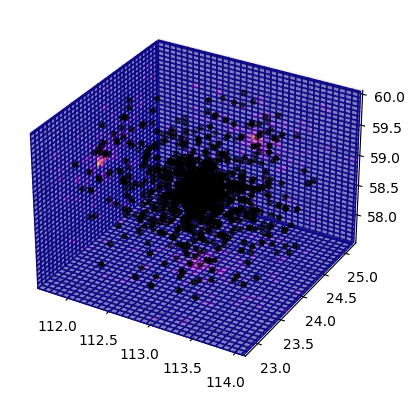

In [13]:
ax = plt.figure().add_subplot(projection='3d')

ax.scatter(x_,y_,z_,marker=(7,1,0),color="black")


ax.plot_surface(
    np.full_like(Y_flat,x_.min()),
    Y_flat,
    Z_flat2,
    facecolors=plt.cm.plasma(H_yz.T/H_yz.max()),
    alpha=0.5,
    shade=False
)


ax.plot_surface(
    X_flat,
    np.full_like(X_flat,y_.max()),
    Z_flat,
    facecolors=plt.cm.plasma(H_xz.T/H_xz.max()),
    alpha=0.5,
    shade=False
)

ax.plot_surface(
    X,
    Y,
    np.full_like(X,z_.min()),
    facecolors=plt.cm.plasma(H_xy.T/H_xy.max()),
    alpha=0.5,
    shade=False
)


ax.set(
    xlim=(x_.min().value,x_.max().value,),
    ylim=(y_.min().value,y_.max().value,),
    zlim=(z_.min().value,z_.max().value,),
)


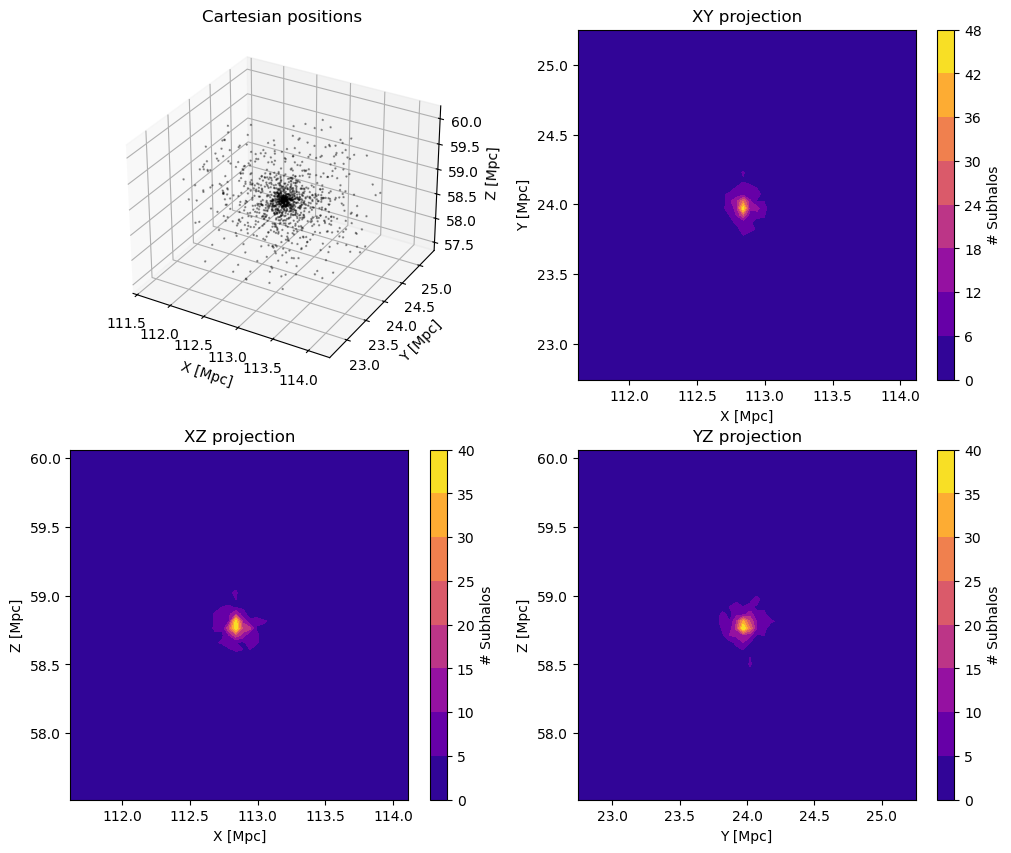

In [ ]:
fig = plt.figure(figsize=(12,10))

ax1 = fig.add_subplot(2,2,1,projection='3d')
ax1.scatter(
    x_,
    y_,
    z_,
    marker=(7,1,0),
    s=5,
    alpha=0.5,
    color="black",
    edgecolors="none"
)

ax1.set_xlabel("X [Mpc]")
ax1.set_ylabel("Y [Mpc]")
ax1.set_zlabel("Z [Mpc]")
ax1.set_title("Cartesian positions")


ax2 = fig.add_subplot(2,2,2)

h2 = ax2.contourf(
    np.histogram2d(
        x_.value,
        y_.value,
        bins=50
    )[0].T,
    extent=[
        x_.value.min(),
        x_.value.max(),
        y_.value.min(),
        y_.value.max(),

    ],
    cmap="plasma"
)

ax2.set_xlabel("X [Mpc]")
ax2.set_ylabel("Y [Mpc]")
ax2.set_title("XY projection")
plt.colorbar(h2,ax=ax2,label="# Subhalos")


ax3 = fig.add_subplot(2,2,3)

h3 = ax3.contourf(
    np.histogram2d(
        x_.value,
        z_.value,
        bins=50
    )[0].T,
    extent=[
        x_.value.min(),
        x_.value.max(),
        z_.value.min(),
        z_.value.max(),

    ],
    cmap="plasma"
)

ax3.set_xlabel("X [Mpc]")
ax3.set_ylabel("Z [Mpc]")
ax3.set_title("XZ projection")
plt.colorbar(h3,ax=ax3,label="# Subhalos")


ax4 = fig.add_subplot(2,2,4)

h4 = ax4.contourf(
    np.histogram2d(
        y_.value,
        z_.value,
        bins=50
    )[0].T,
    extent=[
        y_.value.min(),
        y_.value.max(),
        z_.value.min(),
        z_.value.max(),

    ],
    cmap="plasma"
)

ax4.set_xlabel("Y [Mpc]")
ax4.set_ylabel("Z [Mpc]")
ax4.set_title("YZ projection")
plt.colorbar(h4,ax=ax4,label="# Subhalos")


# plt.savefig("AbelToy_subhalos.png",dpi=300)

In [15]:
masses = sh_pop_table.columns["msh"]
c_subh = sh_pop_table.columns["csh"]

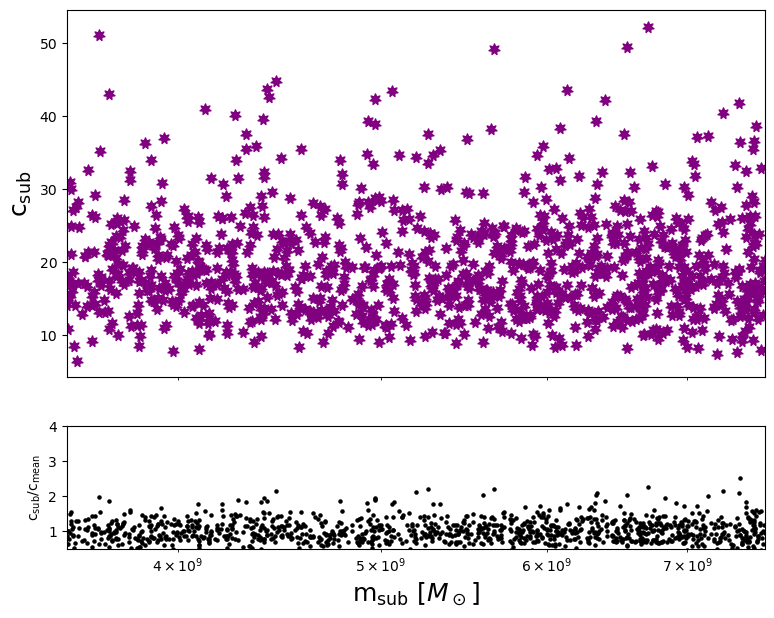

In [ ]:
_,(ax1,ax2) = plt.subplots(figsize=(9,7),nrows=2, ncols=1,gridspec_kw={'height_ratios': [3, 1]},sharex=True)

cmean  = get_c_sub(
    masses,
    sh_pop_table.columns["rsh"],
    abel_cluster.r200,
    abel_cluster.h,
    clabel=abel_cluster.cM_sub
)

ax1.scatter(masses,c_subh,marker=(7,1,0),color="purple",s=65)
ax2.scatter(masses,c_subh/cmean,marker="o",color="black",s=5)

ax1.set_xscale("log")
ax1.set_ylabel(r"c$_\text{sub}$",fontsize=18)

ax1.set_xlim(masses.value.min(),masses.value.max())
ax2.set_ylim(0.5,4)

ax2.set_xlabel(r"m$_\text{sub}$ [$M_\odot$]",fontsize=18)
ax2.set_ylabel(r"c$_\text{sub}$/c$_\text{mean}$")

# plt.savefig("SH_Concentration.png",dpi=200)

In [17]:

sh_pop_table

msh,rsh,xsh,ysh,zsh,csh,r200,rhos,rs,lanna,cross
solMass,kpc,kpc,kpc,kpc,,kpc,solMass / kpc3,kpc,solMass2 / kpc3,solMass2 / kpc3
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
4244831636.712194,254.10300069660943,112674.82540535399,24176.317858026872,58796.73153401406,21.43329396090181,32.174531354411286,46334945.54031573,1.501147299761923,3.042386052882872e+16,3794180064989007.5
4061816571.391988,850.120603750216,112035.6943980497,24249.33834933696,58840.93552597233,14.055182890533553,31.705322543078722,15836395.516505605,2.25577445629917,1.2061896599686806e+16,143297774198746.28
7281868373.690022,282.6229835585275,113099.35795343226,24088.26099425109,58727.82216911246,40.49379652894823,38.515867274472335,244907986.8027204,0.9511547589008624,2.1619922881020522e+17,4981727786444241.0
7237175571.727027,277.0815463801458,112706.97629326014,24067.91808206342,59007.7758928388,25.203443517316934,38.436907879046665,70469461.74768765,1.5250657257464522,7.378708262974131e+16,5205455591279919.0
5270627673.562058,187.09730468526305,112881.94995304671,24167.847312300404,58780.27345298685,17.91024025267717,34.58168782163795,29241611.085187156,1.9308332738009353,2.5786342920281104e+16,9921576880302964.0
4063369162.6274724,379.28636736377763,112953.09600122471,23632.40405434505,58863.3426074017,22.51180127543,31.709361715731493,52591456.82483909,1.408566170595152,3.238054754888169e+16,1300291032327587.0
4344832300.828518,549.3187607531578,112585.75985901625,24459.90257385251,58885.072892548,16.678823216412145,32.425231057193585,24394568.287143115,1.9440958535543924,1.8319200342889624e+16,514969139876890.75
4381537245.641916,290.5718627145192,112814.89188250984,23904.127933378357,59057.84126500029,9.969692963690402,32.51628408952016,6761667.332308891,3.2615130885117916,6649403918491842.0,2793778931231416.5


In [18]:
sh_pop.to_qtable()

msh,rsh,xsh,ysh,zsh,csh,r200,rhos,rs,lanna,cross
solMass,kpc,kpc,kpc,kpc,,kpc,solMass / kpc3,kpc,solMass2 / kpc3,solMass2 / kpc3
float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
4244831636.712194,254.10300069660943,112674.82540535399,24176.317858026872,58796.73153401406,21.43329396090181,32.174531354411286,46334945.54031573,1.501147299761923,3.042386052882872e+16,3794180064989007.5
4061816571.391988,850.120603750216,112035.6943980497,24249.33834933696,58840.93552597233,14.055182890533553,31.705322543078722,15836395.516505605,2.25577445629917,1.2061896599686806e+16,143297774198746.28
7281868373.690022,282.6229835585275,113099.35795343226,24088.26099425109,58727.82216911246,40.49379652894823,38.515867274472335,244907986.8027204,0.9511547589008624,2.1619922881020522e+17,4981727786444241.0
7237175571.727027,277.0815463801458,112706.97629326014,24067.91808206342,59007.7758928388,25.203443517316934,38.436907879046665,70469461.74768765,1.5250657257464522,7.378708262974131e+16,5205455591279919.0
5270627673.562058,187.09730468526305,112881.94995304671,24167.847312300404,58780.27345298685,17.91024025267717,34.58168782163795,29241611.085187156,1.9308332738009353,2.5786342920281104e+16,9921576880302964.0
4063369162.6274724,379.28636736377763,112953.09600122471,23632.40405434505,58863.3426074017,22.51180127543,31.709361715731493,52591456.82483909,1.408566170595152,3.238054754888169e+16,1300291032327587.0
4344832300.828518,549.3187607531578,112585.75985901625,24459.90257385251,58885.072892548,16.678823216412145,32.425231057193585,24394568.287143115,1.9440958535543924,1.8319200342889624e+16,514969139876890.75
4381537245.641916,290.5718627145192,112814.89188250984,23904.127933378357,59057.84126500029,9.969692963690402,32.51628408952016,6761667.332308891,3.2615130885117916,6649403918491842.0,2793778931231416.5


In [19]:
small = SubHaloPopulation.from_qtable(sh_pop.to_qtable()[:100])

In [20]:
sh_pop[0:10]

<SubhaloContainer: 10 subhalos, mass unit=solMass,length unit=kpc>

In [21]:
sh_pop[:100].save_to_fits("AbelSubHaloSample.fits.gz")

In [22]:
lanna_sh = np.sum(sh_pop_table["lanna"])
lcross   = np.sum(sh_pop_table["cross"])
lsmooth  = abel_cluster.l_dm_anna_sub-(lanna_sh+lcross)
boost    = abel_cluster.l_dm_anna_sub/lsmooth

In [23]:
print("Luminosity from all the different contributions:")
print(f"Subhalos: {lanna_sh:0.5e}")
print(f"Cross: {lcross:0.5e}")
print(f"Smooth: {lsmooth:0.5e}")
print(f"Boost factor: {boost}")

Luminosity from all the different contributions:
Subhalos: 4.21779e+19 solMass2 / kpc3
Cross: 4.27072e+19 solMass2 / kpc3
Smooth: 1.04842e+21 solMass2 / kpc3
Boost factor: 1.0809651096409298
